# Inverted Pendulum PID Controller

Demonstration of controlling an inverted pendulum using a PID controller.

**Author:** Shawn Hymel<br>
**Date:** 2023-08-05

Run stm32-stepper-encoder-control.ino on your STM32 Nucleo board. Connect the USB, change the serial port designator, and run through the cells to test controlling the pendulum.

Intended for the following inverted pendulum kit: [STEVAL-EDUKIT01](https://www.st.com/en/evaluation-tools/steval-edukit01.html)

Install the following packages:

```
python -m pip install pyserial
```

**License:** Zero-Clause BSD

Permission to use, copy, modify, and/or distribute this software for
any purpose with or without fee is hereby granted.

THE SOFTWARE IS PROVIDED “AS IS” AND THE AUTHOR DISCLAIMS ALL
WARRANTIES WITH REGARD TO THIS SOFTWARE INCLUDING ALL IMPLIED WARRANTIES
OF MERCHANTABILITY AND FITNESS. IN NO EVENT SHALL THE AUTHOR BE LIABLE
FOR ANY SPECIAL, DIRECT, INDIRECT, OR CONSEQUENTIAL DAMAGES OR ANY
DAMAGES WHATSOEVER RESULTING FROM LOSS OF USE, DATA OR PROFITS, WHETHER IN
AN ACTION OF CONTRACT, NEGLIGENCE OR OTHER TORTIOUS ACTION, ARISING OUT
OF OR IN CONNECTION WITH THE USE OR PERFORMANCE OF THIS SOFTWARE.

In [1]:
from control_comms import ControlComms, StatusCode, DebugLevel
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import math
import numpy as np

In [2]:
# Constants
SERIAL_PORT = "COM10"    # Check your devices
BAUD_RATE = 500000      # Must match what's in the Arduino code!
TIMEOUT = 1.0           # Seconds
DEBUG_LEVEL = DebugLevel.DEBUG_ERROR

In [3]:
# Communication constants
CMD_SET_HOME = 0        # Set current stepper position as home (0 deg)
CMD_MOVE_TO = 1         # Move stepper to a particular position (deg)
CMD_MOVE_BY = 2         # Move stepper by a given amount (deg)
CMD_SET_STEP_MODE = 3   # Set step mode
CMD_SET_BLOCK_MODE = 4  # Set blocking mode
STEP_MODE_1 = 0         # 1 division per step
STEP_MODE_2 = 1         # 2 divisions per step
STEP_MODE_4 = 2         # 4 divisions per step
STEP_MODE_8 = 3         # 8 divisions per step
STEP_MODE_16 = 4        # 16 divisions per step
STATUS_OK = 0           # Stepper idle
STATUS_STP_MOVING = 1   # Stepper is currently moving

In [4]:
# Close connection to Arduino board (if open)
try:
    ctrl.close()
except:
    pass

In [5]:
# Connect to Arduino board
ctrl = ControlComms(timeout=TIMEOUT, debug_level=DEBUG_LEVEL)
ret = ctrl.connect(SERIAL_PORT, BAUD_RATE)
if ret is not StatusCode.OK:
    print("ERROR: Could not connect to board")

In [6]:
resp = ctrl.step(CMD_MOVE_BY, [+90.0])
if resp:
    status, timestamp, terminated, obs = resp
    print(f"Status: {status}")
    print(f"Timestamp: {timestamp}")
    print(f"Terminated: {terminated}")
    print(f"Observation: {obs}")
else:
    print("ERROR: Could not communicate with Arduino")

Status: 1
Timestamp: 874267
Terminated: False
Observation: [2.4, 0.112, 0.0, 65027.0]


In [7]:
CMD_SET_HOME       = 0
CMD_MOVE_TO        = 1
CMD_MOVE_BY        = 2
CMD_SET_STEP_MODE  = 3
CMD_SET_BLOCK_MODE = 4
CMD_RUN            = 5
CMD_STOP           = 6
CMD_SET_SPEED      = 7
CMD_READ           = 8

STATUS_OK          = 0
STATUS_STP_MOVING  = 1
STATUS_LIMIT       = 2
STATUS_DRIVER_FAULT = 3

def move_and_wait(deg, poll_s=0.02):
    resp = ctrl.step(CMD_MOVE_BY, [deg])

    if resp is None:
        raise RuntimeError("MOVE_BY communication failed")

    while True:
        status, timestamp, terminated, obs = resp

        print("raw obs:", obs)

        if len(obs) >= 5:
            print(
                f"\rstatus={status} "
                f"encoder={obs[0]:7.2f} deg "
                f"stepper={obs[1]:7.2f} deg "
                f"enc_cum={obs[2]:7.2f} deg "
                f"stp_cum={obs[3]:7.2f} deg "
                f"speed={obs[4]:7.0f} pps",
                end=""
            )

        elif len(obs) >= 2:
            print(
                f"\rstatus={status} "
                f"encoder={obs[0]:7.2f} deg "
                f"stepper={obs[1]:7.2f} deg",
                end=""
            )

        else:
            print("\nUnexpected observation:", obs)
            break

        if terminated:
            print("\nSafety/fault latch!")
            break

        if status == STATUS_OK:
            print("\nMotion complete.")
            break

        time.sleep(poll_s)
        resp = ctrl.step(CMD_READ, [0.0])

        if resp is None:
            print("\nREAD failed")
            break

In [8]:
resp = ctrl.step(CMD_READ, [0.0])

print(resp)

if resp:
    status, timestamp, terminated, obs = resp
    print("status =", status)
    print("timestamp =", timestamp)
    print("terminated =", terminated)
    print("obs =", obs)
    print("len(obs) =", len(obs))

(1, 874566, False, [337.5, 39.825, 0.0, 65027.0])
status = 1
timestamp = 874566
terminated = False
obs = [337.5, 39.825, 0.0, 65027.0]
len(obs) = 4


In [9]:
move_and_wait(+90.0)

raw obs: [329.1, 68.512, 0.0, 65027.0]
status=1 encoder= 329.10 deg stepper=  68.51 degraw obs: [330.6, 74.7, 0.0, 65027.0]
status=1 encoder= 330.60 deg stepper=  74.70 degraw obs: [333.6, 79.537, 0.0, 65027.0]
status=1 encoder= 333.60 deg stepper=  79.54 degraw obs: [337.8, 83.588, 0.0, 65027.0]
status=1 encoder= 337.80 deg stepper=  83.59 degraw obs: [345.0, 86.963, 0.0, 65027.0]
status=1 encoder= 345.00 deg stepper=  86.96 degraw obs: [352.2, 89.1, 0.0, 65027.0]
status=1 encoder= 352.20 deg stepper=  89.10 degraw obs: [1.2, 90.113, 0.0, 65027.0]
status=0 encoder=   1.20 deg stepper=  90.11 deg
Motion complete.


In [10]:
resp = ctrl.step(CMD_MOVE_BY, [-90.0])
if resp:
    status, timestamp, terminated, obs = resp
    print(f"Status: {status}")
    print(f"Timestamp: {timestamp}")
    print(f"Terminated: {terminated}")
    print(f"Observation: {obs}")
else:
    print("ERROR: Could not communicate with Arduino")

Status: 1
Timestamp: 875160
Terminated: False
Observation: [35.7, 90.113, 0.0, 65027.0]


In [11]:
# Test control
resp = ctrl.step(CMD_SET_STEP_MODE, [STEP_MODE_16])
resp = ctrl.step(CMD_SET_BLOCK_MODE, [1])
resp = ctrl.step(CMD_SET_HOME, [0])
resp = ctrl.step(CMD_MOVE_BY, [+90.0])
if resp:
    status, timestamp, terminated, obs = resp
    print(f"Status: {status}")
    print(f"Timestamp: {timestamp}")
    print(f"Terminated: {terminated}")
    print(f"Observation: {obs}")
else:
    print("ERROR: Could not communicate with Arduino")

Status: 1
Timestamp: 875367
Terminated: False
Observation: [347.4, 0.0, 0.0, 65027.0]


## State-feedback controller with the $G_{\rm rotor} = 1$ assumption

The cells below implement the controller from `chatgpt/simple_G1.md`. The Arduino sketch only accepts **position** commands (`CMD_MOVE_TO`, `CMD_MOVE_BY`) — it cannot take an acceleration command directly — so the state feedback

$$\ddot\phi_{\rm cmd} = -k_\theta\,\theta_{\rm err} - k_{\dot\theta}\,\dot\theta_{\rm est} - k_\phi\,(\phi - \phi_{\rm ref}) - k_{\dot\phi}\,\dot\phi_{\rm est}$$

is converted each sample into a relative displacement sent via `CMD_MOVE_BY`:

$$\Delta\phi_{\rm cmd} = \dot\phi_{\rm est}\,T_s + \tfrac{1}{2}\,\ddot\phi_{\rm cmd}\,T_s^2$$

Key points:

- $\dot\phi_{\rm est}$ is obtained by differentiating the **measured** rotor angle every sample — there is no internal $\dot\phi_{\rm des}$ integrator, so there is no command integrator drift.
- The encoder and rotor angles arrive wrapped to $0°\sim360°$, so they are unwrapped before differentiating (otherwise $359°\to0°$ produces a huge fake velocity).
- $T_s$ is the **actual** interval computed from the Arduino `millis()` timestamps, not a fixed constant (Jupyter + serial timing is not uniform).
- The .ino truncates degrees to an integer number of microsteps, so commands are quantized to whole microsteps and the fractional residual is carried over in the notebook.

This is a *kinematic approximation*: it assumes the stepper follows each position increment within one sample period, i.e. $G_{\rm rotor} \approx 1$. The L6474's own limits (3000 pps² accel/decel, 1000 pps max speed) still apply, so $\ddot\phi_{\rm actual} = \ddot\phi_{\rm cmd}$ is not guaranteed.

In [12]:
def angle_diff_rad(current, previous):
    """
    Minimum difference between two wrapped angles.
    Result: [-pi, pi)
    """
    d = current - previous
    return (d + np.pi) % (2.0 * np.pi) - np.pi


class PendulumStateController:
    """
    State-feedback controller under the G_rotor = 1 assumption.

    phi_ddot_cmd = -k_theta*theta_err - k_theta_dot*theta_dot_est
                   -k_phi*(phi - phi_ref) - k_phi_dot*phi_dot_est

    is converted to a relative displacement for CMD_MOVE_BY:

    delta_phi = phi_dot_est*dt + 0.5*phi_ddot_cmd*dt^2

    phi_dot_est is differentiated from the MEASURED rotor angle each
    sample (no internal phi_dot_des integrator -> no command drift).
    Internally everything is in radians.
    """

    def __init__(
        self,
        k_theta,
        k_theta_dot,
        k_phi,
        k_phi_dot,
        theta_ref_deg=0.0,
        phi_ref_deg=0.0,
        derivative_tau=0.02,
        max_accel_rad_s2=20.0,
    ):
        self.k_theta = k_theta
        self.k_theta_dot = k_theta_dot

        self.k_phi = k_phi
        self.k_phi_dot = k_phi_dot

        self.theta_ref = np.deg2rad(theta_ref_deg)
        self.phi_ref = np.deg2rad(phi_ref_deg)

        self.tau = derivative_tau

        self.max_accel = max_accel_rad_s2

        self.initialized = False

        self.theta_prev = 0.0
        self.phi_prev_wrapped = 0.0

        # Continuous/unwrapped position of the actual rotor
        self.phi_unwrapped = 0.0

        self.theta_dot = 0.0
        self.phi_dot = 0.0

    def initialize(self, theta_deg, phi_deg):
        theta = np.deg2rad(theta_deg)
        phi = np.deg2rad(phi_deg)

        self.theta_prev = theta
        self.phi_prev_wrapped = phi

        self.phi_unwrapped = phi

        self.theta_dot = 0.0
        self.phi_dot = 0.0

        self.initialized = True

    def update(self, theta_deg, phi_deg, dt):

        theta_wrapped = np.deg2rad(theta_deg)
        phi_wrapped = np.deg2rad(phi_deg)

        if not self.initialized:
            self.initialize(theta_deg, phi_deg)
            return 0.0, 0.0, 0.0

        # --------------------------------------------
        # 1. Unwrap the actual rotor position
        # --------------------------------------------
        dphi = angle_diff_rad(phi_wrapped, self.phi_prev_wrapped)
        self.phi_unwrapped += dphi

        # --------------------------------------------
        # 2. Pendulum angle error
        #    (minimum angle error around theta_ref)
        # --------------------------------------------
        theta_error = angle_diff_rad(theta_wrapped, self.theta_ref)

        # --------------------------------------------
        # 3. Numerical derivatives
        # --------------------------------------------
        dtheta = angle_diff_rad(theta_wrapped, self.theta_prev)

        theta_dot_raw = dtheta / dt
        phi_dot_raw = dphi / dt

        # --------------------------------------------
        # 4. Derivative low-pass filter
        #    alpha = tau / (tau + dt)
        # --------------------------------------------
        alpha = self.tau / (self.tau + dt)

        self.theta_dot = (
            alpha * self.theta_dot
            + (1.0 - alpha) * theta_dot_raw
        )

        self.phi_dot = (
            alpha * self.phi_dot
            + (1.0 - alpha) * phi_dot_raw
        )

        # --------------------------------------------
        # 5. Rotor position error
        # --------------------------------------------
        phi_error = self.phi_unwrapped - self.phi_ref

        # --------------------------------------------
        # 6. Desired rotor acceleration
        # --------------------------------------------
        phi_ddot_cmd = (
            -self.k_theta * theta_error
            - self.k_theta_dot * self.theta_dot
            - self.k_phi * phi_error
            - self.k_phi_dot * self.phi_dot
        )

        phi_ddot_cmd = np.clip(
            phi_ddot_cmd,
            -self.max_accel,
            self.max_accel
        )

        # --------------------------------------------
        # 7. Acceleration -> relative displacement
        #    delta_phi = v*dt + 0.5*a*dt^2
        #    v is the velocity estimate from the measured phi,
        #    NOT a desired velocity (G_rotor = 1 assumption)
        # --------------------------------------------
        delta_phi_cmd = (
            self.phi_dot * dt
            + 0.5 * phi_ddot_cmd * dt**2
        )

        # Save for the next iteration
        self.theta_prev = theta_wrapped
        self.phi_prev_wrapped = phi_wrapped

        # Arduino CMD_MOVE_BY takes degrees
        delta_phi_deg = np.rad2deg(delta_phi_cmd)

        return (
            delta_phi_deg,
            phi_ddot_cmd,
            self.phi_dot
        )

In [13]:
# The .ino truncates degrees -> int steps, so sub-step commands would be
# silently dropped. Quantize each command to whole microsteps and keep the
# fractional residual on the notebook side so it is not lost.

STEP_DIVS = {
    STEP_MODE_1: 1,
    STEP_MODE_2: 2,
    STEP_MODE_4: 4,
    STEP_MODE_8: 8,
    STEP_MODE_16: 16,
}

step_residual_deg = 0.0

def quantize_relative_command(delta_deg, step_deg):
    global step_residual_deg

    total = delta_deg + step_residual_deg

    n_steps = math.trunc(total / step_deg)

    send_deg = n_steps * step_deg

    step_residual_deg = total - send_deg

    return send_deg

### Physical configuration (from *Introduction to Integrated Rotary Inverted Pendulum v2*)

| Parameter | Value | Note |
|---|---|---|
| Pendulum length $l$ | 0.235 m | rotor arm to supported mass (Table 2) |
| Rotor arm length $r$ | 0.14 m | Table 2 |
| Natural frequency $\omega_0 = \sqrt{g/l}$ | ≈ 6.46 rad/s | open-loop unstable pole at $+6.46$ |
| Damping | $\omega_0/Q$, $Q = 10$ | ≈ 0.65 s⁻¹, small enough to ignore in gain design |
| Pendulum encoder | 2400 counts/rev | 0.15°/count (LPD3806-600BM) |
| Stepper | 200 steps/rev, 1/16 microstep | 0.1125°/microstep |
| Max acceleration | 3000 pps² | ≈ 337.5°/s² ≈ **5.9 rad/s²** at 1/16 |
| Max speed | 1000 pps | ≈ 112.5°/s ≈ **2.0 rad/s** at 1/16 |

Small-angle model about upright, with $d = g/l \approx 41.74$ s⁻² and $e = r/l \approx 0.596$ (the sign of $e$ as seen by this firmware depends on mounting/encoder directions — `COUPLING_SIGN` below):

$$\ddot\theta_{\rm err} = d\,\theta_{\rm err} + e\,\ddot\phi$$

With $u = \ddot\phi_{\rm cmd} = -k_\theta\theta_{\rm err} - k_{\dot\theta}\dot\theta_{\rm err} - k_\phi\phi - k_{\dot\phi}\dot\phi$ and $\ddot\phi = u$ ($G_{\rm rotor}=1$), the closed-loop characteristic polynomial is

$$s^4 + (e k_{\dot\theta} + k_{\dot\phi})\,s^3 + (e k_\theta + k_\phi - d)\,s^2 - d k_{\dot\phi}\,s - d k_\phi = 0$$

so the gains follow from a desired pole set by matching coefficients (done in the next cell). Note that stability requires $k_\phi < 0$ and $k_{\dot\phi} < 0$ — the rotor-angle gains must be *negative*.

**Caveats from the manual:**
- The measured rotor response is $G_{\rm Rotor}(s) = a/(s^2+bs+c)$ with $c \approx 0.44$–$0.55$ (corner ≈ 0.7 rad/s) for the Max/Min-speed configurations of Table 4 — a second-order lag, *not* 1, and much slower than $\omega_0 \approx 6.5$ rad/s. The $G_{\rm rotor}=1$ assumption is therefore only reasonable because we command small incremental moves each sample; expect degraded performance vs. the model.
- The actuator saturates at ≈5.9 rad/s²: with the pole-placement gains below, saturation is reached at roughly 1.3° of pendulum error, so the balance basin is narrow — start the pendulum very close to upright.
- If the pendulum falls away *faster* the moment the controller runs, flip `COUPLING_SIGN` in the next cell (the UCLA manual itself notes its positive rotor command produces a negative rotor angle).

K_THETA     =   228.57 rad/s^2 per rad
K_THETA_DOT =    29.64 rad/s^2 per rad/s
K_PHI       =    -2.15 rad/s^2 per rad
K_PHI_DOT   =    -4.06 rad/s^2 per rad/s
Accel clip  = 5.30 rad/s^2 (saturates at ~1.33 deg of pendulum error)
Error parsing message. Message received: "status":1,"timestamp":977380,"terminated":false,"observation":[1.800,-46.575,0.000,65027.000]}

Average interval: 6.497 ms


Text(0.5, 0, 'Step')

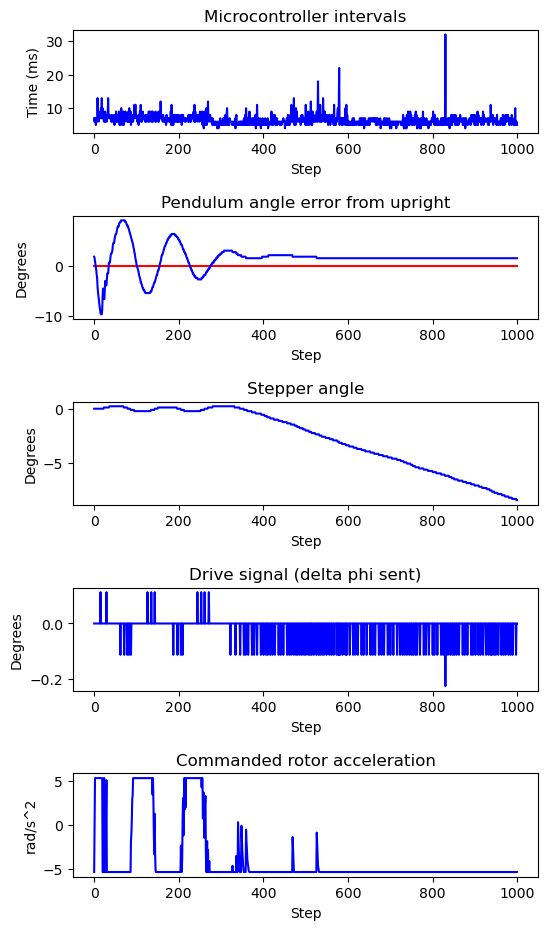

In [16]:
# ------------------------------------------------------------------
# Physical parameters (manual, Table 2) and simplified model
#   theta_ddot = d*theta_err + e*phi_ddot   (inverted, G_rotor = 1)
# ------------------------------------------------------------------
G_ACCEL = 9.81      # m/s^2
PEND_L = 0.235      # m, rotor arm to pendulum mass
ROTOR_R = 0.14      # m, rotor arm length

d_pend = G_ACCEL / PEND_L               # g/l ~ 41.74 s^-2 (unstable pole +-6.46)

# Coupling direction between rotor acceleration and pendulum angle as seen
# by THIS firmware. Flip to -1.0 if the pendulum falls away faster as soon
# as the controller runs.
COUPLING_SIGN = 1.0
e_pend = COUPLING_SIGN * (ROTOR_R / PEND_L)   # r/l ~ 0.596

# ------------------------------------------------------------------
# Gain design by pole placement.
# With u = phi_ddot_cmd = -k_t*th - k_td*th_dot - k_p*phi - k_pd*phi_dot
# the closed-loop characteristic polynomial is
#   s^4 + (e*k_td + k_pd)s^3 + (e*k_t + k_p - d)s^2 - d*k_pd*s - d*k_p
# Pendulum pair: zeta=0.7, wn=8 rad/s (above omega0 = 6.46 rad/s).
# Rotor pair: slow real poles so phi returns to phi_ref gently.
# ------------------------------------------------------------------
ZETA_PEND = 0.7
WN_PEND = 8.0
POLES_ROTOR = [-1.0, -1.4]

poles_pend = np.roots([1.0, 2.0 * ZETA_PEND * WN_PEND, WN_PEND**2])
dpoly = np.real(np.poly(np.concatenate([poles_pend, POLES_ROTOR])))

K_PHI       = -dpoly[4] / d_pend
K_PHI_DOT   = -dpoly[3] / d_pend
K_THETA_DOT = (dpoly[1] - K_PHI_DOT) / e_pend
K_THETA     = (dpoly[2] + d_pend - K_PHI) / e_pend

# Other controller constants
THETA_REF_DEG = 0.0         # Upright pendulum encoder angle (encoder reads
                            # 0/360 deg at upright; wrap handled internally)
PHI_REF_DEG = 0.0           # Rotor reference (home)
DERIVATIVE_TAU = 0.02       # Derivative low-pass filter time constant (s)
NUM_STEPS = 1000

# Optional guard: stop the loop if the pendulum error from upright exceeds
# this many degrees. Disabled by default -- set USE_ENC_GUARD = True.
USE_ENC_GUARD = False
ENC_GUARD_ERR_DEG = 25.0

STEP_MODE = STEP_MODE_16

# One microstep in degrees (0.1125 deg at 1/16)
STEP_DEG = 360.0 / (200 * STEP_DIVS[STEP_MODE])

# Actuator limits from the .ino config: 3000 pps^2, 1000 pps at 1/16
# microstep -> ~5.9 rad/s^2 and ~2.0 rad/s. Clip commands below the
# hardware limit so the G_rotor = 1 assumption stays plausible.
ACCEL_HW_RAD_S2 = np.deg2rad(3000 * STEP_DEG)
MAX_ACCEL_RAD_S2 = 0.9 * ACCEL_HW_RAD_S2

print(f"K_THETA     = {K_THETA:8.2f} rad/s^2 per rad")
print(f"K_THETA_DOT = {K_THETA_DOT:8.2f} rad/s^2 per rad/s")
print(f"K_PHI       = {K_PHI:8.2f} rad/s^2 per rad")
print(f"K_PHI_DOT   = {K_PHI_DOT:8.2f} rad/s^2 per rad/s")
print(f"Accel clip  = {MAX_ACCEL_RAD_S2:.2f} rad/s^2 "
      f"(saturates at ~{np.rad2deg(MAX_ACCEL_RAD_S2 / K_THETA):.2f} deg of pendulum error)")

# Controller (G_rotor = 1 assumption)
controller = PendulumStateController(
    k_theta=K_THETA,
    k_theta_dot=K_THETA_DOT,
    k_phi=K_PHI,
    k_phi_dot=K_PHI_DOT,
    theta_ref_deg=THETA_REF_DEG,
    phi_ref_deg=PHI_REF_DEG,
    derivative_tau=DERIVATIVE_TAU,
    max_accel_rad_s2=MAX_ACCEL_RAD_S2,
)
step_residual_deg = 0.0

# Metrics to store
intervals = []
enc_err_degs = []
stp_degs = []
move_degs = []
accel_cmds = []

# Set step mode, non-blocking moves, current position as home, get timestamp
resp = ctrl.step(CMD_SET_STEP_MODE, [STEP_MODE])
resp = ctrl.step(CMD_SET_BLOCK_MODE, [0])
resp = ctrl.step(CMD_SET_HOME, [0])
if resp:
    _, timestamp_prev, _, obs = resp
    controller.initialize(obs[0], obs[1])
else:
    print("ERROR: Could not communicate with Arduino")
    timestamp_prev = 0

# Try to keep pendulum in upright position
delta_phi_send = 0.0
for i in range(NUM_STEPS):

    # Send the relative move and get an observation back
    resp = ctrl.step(CMD_MOVE_BY, [delta_phi_send])
    if resp:
        status, timestamp, terminated, obs = resp
    else:
        print("ERROR: Could not communicate with Arduino")
        continue

    # Get observation values (deg, wrapped to 0~360)
    enc_deg = obs[0]    # Pendulum encoder angle (theta)
    stp_deg = obs[1]    # Stepper rotor angle (phi)

    # Pendulum error from upright, wrapped to [-180, 180)
    enc_err_deg = np.rad2deg(angle_diff_rad(np.deg2rad(enc_deg),
                                            np.deg2rad(THETA_REF_DEG)))

    # Actual sample time from the microcontroller timestamps (ms -> s)
    interval = timestamp - timestamp_prev
    timestamp_prev = timestamp
    dt = interval / 1000.0

    # Skip abnormal sample periods
    if dt <= 0.0 or dt > 0.1:
        delta_phi_send = 0.0
        continue

    # State feedback -> relative displacement (G_rotor = 1 assumption)
    delta_phi_deg, phi_ddot_cmd, phi_dot_est = controller.update(
        enc_deg,
        stp_deg,
        dt
    )

    # Quantize to whole microsteps, carrying the fractional residual
    delta_phi_send = quantize_relative_command(delta_phi_deg, STEP_DEG)

    # Store metrics
    intervals.append(interval)
    move_degs.append(delta_phi_send)
    enc_err_degs.append(enc_err_deg)
    stp_degs.append(stp_deg)
    accel_cmds.append(phi_ddot_cmd)

    # Optional stop if the pendulum has fallen too far from upright
    if USE_ENC_GUARD and abs(enc_err_deg) > ENC_GUARD_ERR_DEG:
        print("Episode terminated")
        break

# Calculate average interval
print(f"Average interval: {sum(intervals) / len(intervals)} ms")

# Create plots
fig, ax = plt.subplots(5, 1, figsize=(6, 11))
plt.subplots_adjust(hspace=0.8)

# Plot intervals measured from microcontroller
ax[0].plot(intervals, color='blue')
ax[0].set_title("Microcontroller intervals")
ax[0].set_ylabel("Time (ms)")
ax[0].set_xlabel("Step")

# Plot pendulum angle error from upright
ax[1].plot([0.0] * len(enc_err_degs), color='red')
ax[1].plot(enc_err_degs, color='blue')
ax[1].set_title("Pendulum angle error from upright")
ax[1].set_ylabel("Degrees")
ax[1].set_xlabel("Step")

# Plot stepper degrees
ax[2].plot(stp_degs, color='blue')
ax[2].set_title("Stepper angle")
ax[2].set_ylabel("Degrees")
ax[2].set_xlabel("Step")

# Plot output signals (relative moves actually sent)
ax[3].plot(move_degs, color='blue')
ax[3].set_title("Drive signal (delta phi sent)")
ax[3].set_ylabel("Degrees")
ax[3].set_xlabel("Step")

# Plot commanded rotor acceleration
ax[4].plot(accel_cmds, color='blue')
ax[4].set_title("Commanded rotor acceleration")
ax[4].set_ylabel("rad/s^2")
ax[4].set_xlabel("Step")

## LQR controller from the manual (Section 15)

The cells below implement the manual's own design instead of the $G_{\rm rotor}=1$ simplification above. The difference: the **identified rotor dynamics are part of the plant model**, and the control input is the rotor angle command itself, not an acceleration.

$$\ddot\phi = -b\dot\phi - c\phi + a\,u, \qquad \ddot\theta = e\,\ddot\phi + d\,\theta, \qquad u = \phi_{RC}$$

State vector and state-space form (manual, p.105–106):

$$x = [\phi,\ \dot\phi,\ \theta,\ \dot\theta]^T,\qquad \dot x = Ax + Bu,\qquad u = -Kx$$

$K$ minimizes $J = \int_0^\infty (x^TQx + u^TRu)\,dt$ with $Q = I$, $R = 1$ (the manual's weights). The rotor coefficients come from Table 5 (medium speed, $Min_{Speed}=200$, $Max_{Speed}=1000$: $b=1.12$, $c=0.49$), identified with correlation > 0.999.

Implementation notes:

- The manual computes $K$ in *step-count* units (which is why its Table 5 has $a = c/2$: control steps are half the size of measurement steps). Here the same design is done in **physical angle units** (unity rotor DC gain, $a = c$). Converting the manual's published medium-speed gains (p.108) to angle units gives $\approx [2.1,\ 5.1,\ 343,\ 53]$ — this notebook's design cell computes $K \approx [2.4,\ 5.5,\ 352,\ 54]$, i.e. the same controller up to the unit convention of $Q$.
- $u$ is an **absolute rotor angle target**: the manual's motor command mode supplies a new target angle every control cycle. With this .ino that is realized by sending `CMD_MOVE_BY` $(u - \phi_{\rm measured})$ each cycle (equivalent to updating the target), with the usual microstep quantization.
- The pendulum gain is large ($u$ swings ≈3.5° of rotor target per 0.01 rad of $\theta$ error) — that is the manual's design too; the rotor's own lag $G_{\rm Rotor}$ smooths the response, which is exactly why the rotor model belongs in the plant.
- State estimation (unwrap + filtered derivatives from the real $dt$) is identical to the $G_{\rm rotor}=1$ controller above.
- Because the rotor lag is *inside* the model, this controller does **not** rely on the $G_{\rm rotor}=1$ kinematic approximation — this is the manual's answer to the limitation noted earlier.

In [17]:
# ------------------------------------------------------------------
# LQR design following the manual, Section 15.
#
# Rotor model (Section 4, Table 5):  phi_ddot = -b*phi_dot - c*phi + a*u
# Pendulum coupling:                 theta_ddot = e*phi_ddot + d*theta
# State x = [phi, phi_dot, theta, theta_dot], input u = phi_RC.
#
#   A = [[ 0,    1,   0, 0],        B = [ 0,
#        [-c,   -b,   0, 0],              a,
#        [ 0,    0,   0, 1],              0,
#        [-c*e, -b*e, d, 0]]              a*e]
#
# Table 5 coefficients (step-count units, where a = c/2 because control
# steps are half the size of measurement steps):
#   High speed   (Min=300, Max=1000): b = 0.90, c = 0.44
#   Medium speed (Min=200, Max=1000): b = 1.12, c = 0.49
#   Low speed    (Min=200, Max=200):  b = 1.89, c = 0.55
# Working in physical angle units the DC gain is unity, so a = c here.
# ------------------------------------------------------------------
B_ROTOR = 1.12      # Medium speed configuration (closest to this .ino)
C_ROTOR = 0.49
A_ROTOR = C_ROTOR   # unity DC gain in physical angle units

LQR_G_ACCEL = 9.81
LQR_PEND_L = 0.235      # m (Table 2)
LQR_ROTOR_R = 0.14      # m (Table 2)

d_lqr = LQR_G_ACCEL / LQR_PEND_L        # g/l ~ 41.74 s^-2

# Coupling direction as seen by this firmware (see COUPLING_SIGN above);
# flip to -1.0 if the pendulum falls harder when the controller runs.
LQR_COUPLING_SIGN = 1.0
e_lqr = LQR_COUPLING_SIGN * (LQR_ROTOR_R / LQR_PEND_L)   # r/l ~ 0.596

A_lqr = np.array([
    [0.0,              1.0,             0.0,   0.0],
    [-C_ROTOR,         -B_ROTOR,        0.0,   0.0],
    [0.0,              0.0,             0.0,   1.0],
    [-C_ROTOR * e_lqr, -B_ROTOR * e_lqr, d_lqr, 0.0],
])
B_lqr = np.array([0.0, A_ROTOR, 0.0, A_ROTOR * e_lqr])

# Controllability check (manual: rank must be 4)
Mc = np.column_stack([
    B_lqr,
    A_lqr @ B_lqr,
    np.linalg.matrix_power(A_lqr, 2) @ B_lqr,
    np.linalg.matrix_power(A_lqr, 3) @ B_lqr,
])
print(f"Controllability matrix rank: {np.linalg.matrix_rank(Mc)} (need 4)")

# Cost weights per the manual: Q = I, R = 1
Q_lqr = np.eye(4)
R_lqr = np.array([[1.0]])


def lqr_gain(A, B, Q, R):
    """Continuous-time LQR via the Hamiltonian eigenvector method
    (numpy only, no scipy needed). Returns K for u = -K x."""
    B = B.reshape(-1, 1)
    Rinv = np.linalg.inv(R)
    n = A.shape[0]
    H = np.block([
        [A,            -B @ Rinv @ B.T],
        [-Q,           -A.T],
    ])
    w, V = np.linalg.eig(H)
    Vs = V[:, w.real < 0]           # stable eigenvectors
    X1, X2 = Vs[:n, :], Vs[n:, :]
    P = np.real(X2 @ np.linalg.inv(X1))
    return (Rinv @ B.T @ P).ravel()


K_LQR = lqr_gain(A_lqr, B_lqr, Q_lqr, R_lqr)

cl_poles = np.linalg.eigvals(A_lqr - B_lqr.reshape(-1, 1) * K_LQR)
print(f"K_LQR (phi, phi_dot, theta, theta_dot) = {np.round(K_LQR, 2)}")
print(f"Closed-loop poles: {np.round(cl_poles, 3)}")
assert np.all(cl_poles.real < 0), "closed loop is not stable -- check signs"

Controllability matrix rank: 4 (need 4)
K_LQR (phi, phi_dot, theta, theta_dot) = [ -2.41  -5.54 351.79  54.46]
Closed-loop poles: [-6.608+0.j    -6.318+0.j    -0.689+0.467j -0.689-0.467j]


In [18]:
class LQRRotorTargetController:
    """
    LQR state-feedback controller from the manual, Section 15.

    State x = [phi, phi_dot, theta_err, theta_dot] (rad, rad/s), estimated
    from the wrapped angle measurements exactly like PendulumStateController
    (unwrap + filtered numerical derivatives). Output is the Rotor Angle
    Control input u = phi_RC = -K x, an ABSOLUTE rotor angle target (deg)
    relative to home, to be sent as a position command.
    """

    def __init__(
        self,
        K,
        theta_ref_deg=0.0,
        phi_ref_deg=0.0,
        derivative_tau=0.02,
        u_max_deg=60.0,
    ):
        self.K = np.asarray(K, dtype=float)

        self.theta_ref = np.deg2rad(theta_ref_deg)
        self.phi_ref = np.deg2rad(phi_ref_deg)

        self.tau = derivative_tau
        self.u_max = np.deg2rad(u_max_deg)

        self.initialized = False

        self.theta_prev = 0.0
        self.phi_prev_wrapped = 0.0
        self.phi_unwrapped = 0.0

        self.theta_dot = 0.0
        self.phi_dot = 0.0

    def initialize(self, theta_deg, phi_deg):
        theta = np.deg2rad(theta_deg)
        phi = np.deg2rad(phi_deg)

        self.theta_prev = theta
        self.phi_prev_wrapped = phi
        self.phi_unwrapped = phi

        self.theta_dot = 0.0
        self.phi_dot = 0.0

        self.initialized = True

    def update(self, theta_deg, phi_deg, dt):
        """Returns (u_deg, phi_unwrapped_deg)."""

        theta_wrapped = np.deg2rad(theta_deg)
        phi_wrapped = np.deg2rad(phi_deg)

        if not self.initialized:
            self.initialize(theta_deg, phi_deg)
            return 0.0, np.rad2deg(self.phi_unwrapped)

        # Unwrap rotor angle and estimate derivatives (filtered)
        dphi = angle_diff_rad(phi_wrapped, self.phi_prev_wrapped)
        self.phi_unwrapped += dphi

        theta_error = angle_diff_rad(theta_wrapped, self.theta_ref)
        dtheta = angle_diff_rad(theta_wrapped, self.theta_prev)

        alpha = self.tau / (self.tau + dt)
        self.theta_dot = alpha * self.theta_dot + (1.0 - alpha) * (dtheta / dt)
        self.phi_dot = alpha * self.phi_dot + (1.0 - alpha) * (dphi / dt)

        phi_error = self.phi_unwrapped - self.phi_ref

        # LQR state feedback: u = -K x (phi_RC, rad)
        x = np.array([phi_error, self.phi_dot, theta_error, self.theta_dot])
        u = float(-self.K @ x)
        u = np.clip(u, -self.u_max, self.u_max)

        self.theta_prev = theta_wrapped
        self.phi_prev_wrapped = phi_wrapped

        return np.rad2deg(u), np.rad2deg(self.phi_unwrapped)

Error parsing message. Message received: ,"timestamp":1037314,"terminated":false,"observation":[10.800,1.913,0.000,65027.000]}

Average interval: 6.897897897897898 ms


Text(0.5, 0, 'Step')

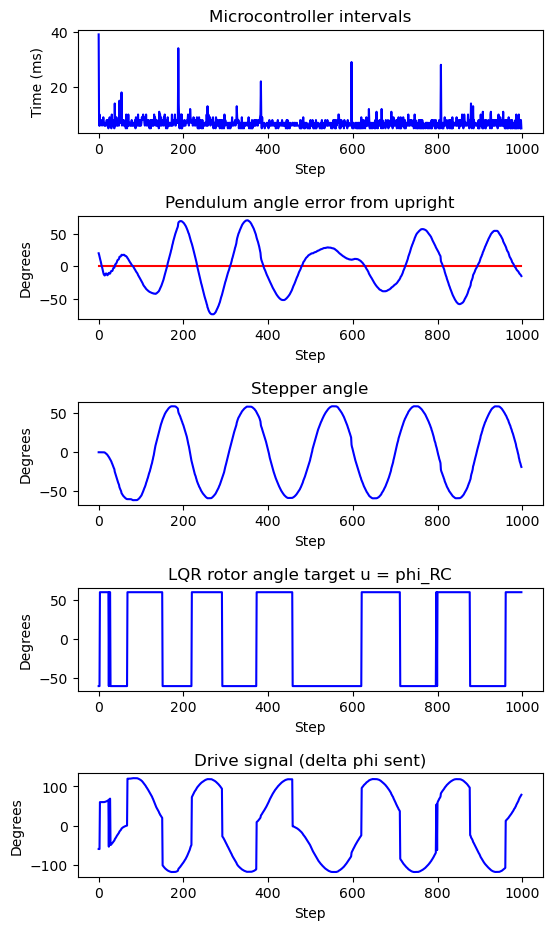

In [20]:
# ------------------------------------------------------------------
# LQR control loop (PDF Section 15). Same communication pattern as the
# G_rotor = 1 loop above, but u is an absolute rotor angle target:
# each cycle we send CMD_MOVE_BY (u_target - phi_measured).
# ------------------------------------------------------------------
LQR_THETA_REF_DEG = 0.0     # Upright pendulum encoder angle (0/360 deg)
LQR_PHI_REF_DEG = 0.0
LQR_NUM_STEPS = 1000

# Optional guard, disabled by default: stop if the pendulum error from
# upright exceeds this many degrees.
LQR_USE_ENC_GUARD = False
LQR_ENC_GUARD_ERR_DEG = 25.0

STEP_MODE = STEP_MODE_16
STEP_DEG = 360.0 / (200 * STEP_DIVS[STEP_MODE])

lqr_controller = LQRRotorTargetController(
    K_LQR,
    theta_ref_deg=LQR_THETA_REF_DEG,
    phi_ref_deg=LQR_PHI_REF_DEG,
    derivative_tau=0.02,
    u_max_deg=60.0,
)
step_residual_deg = 0.0

# Metrics
lqr_intervals = []
lqr_enc_err_degs = []
lqr_stp_degs = []
lqr_u_degs = []
lqr_move_degs = []

resp = ctrl.step(CMD_SET_STEP_MODE, [STEP_MODE])
resp = ctrl.step(CMD_SET_BLOCK_MODE, [0])
resp = ctrl.step(CMD_SET_HOME, [0])
if resp:
    _, timestamp_prev, _, obs = resp
    lqr_controller.initialize(obs[0], obs[1])
else:
    print("ERROR: Could not communicate with Arduino")
    timestamp_prev = 0

delta_phi_send = 0.0
for i in range(LQR_NUM_STEPS):

    resp = ctrl.step(CMD_MOVE_BY, [delta_phi_send])
    if resp:
        status, timestamp, terminated, obs = resp
    else:
        print("ERROR: Could not communicate with Arduino")
        continue

    enc_deg = obs[0]    # Pendulum encoder angle (theta)
    stp_deg = obs[1]    # Stepper rotor angle (phi, wrapped)

    # Pendulum error from upright, wrapped to [-180, 180)
    enc_err_deg = np.rad2deg(angle_diff_rad(np.deg2rad(enc_deg),
                                            np.deg2rad(LQR_THETA_REF_DEG)))

    interval = timestamp - timestamp_prev
    timestamp_prev = timestamp
    dt = interval / 1000.0

    if dt <= 0.0 or dt > 0.1:
        delta_phi_send = 0.0
        continue

    # LQR: u = -Kx is the desired ABSOLUTE rotor angle (phi_RC, deg)
    u_deg, phi_unwrapped_deg = lqr_controller.update(enc_deg, stp_deg, dt)

    # Convert the target to a relative move from the current rotor angle
    delta_phi_deg = u_deg - phi_unwrapped_deg
    delta_phi_send = quantize_relative_command(delta_phi_deg, STEP_DEG)

    lqr_intervals.append(interval)
    lqr_enc_err_degs.append(enc_err_deg)
    lqr_stp_degs.append(stp_deg)
    lqr_u_degs.append(u_deg)
    lqr_move_degs.append(delta_phi_send)

    # Optional stop if the pendulum has fallen too far from upright
    if LQR_USE_ENC_GUARD and abs(enc_err_deg) > LQR_ENC_GUARD_ERR_DEG:
        print("Episode terminated")
        break

print(f"Average interval: {sum(lqr_intervals) / len(lqr_intervals)} ms")

fig, ax = plt.subplots(5, 1, figsize=(6, 11))
plt.subplots_adjust(hspace=0.8)

ax[0].plot(lqr_intervals, color='blue')
ax[0].set_title("Microcontroller intervals")
ax[0].set_ylabel("Time (ms)")
ax[0].set_xlabel("Step")

ax[1].plot([0.0] * len(lqr_enc_err_degs), color='red')
ax[1].plot(lqr_enc_err_degs, color='blue')
ax[1].set_title("Pendulum angle error from upright")
ax[1].set_ylabel("Degrees")
ax[1].set_xlabel("Step")

ax[2].plot(lqr_stp_degs, color='blue')
ax[2].set_title("Stepper angle")
ax[2].set_ylabel("Degrees")
ax[2].set_xlabel("Step")

ax[3].plot(lqr_u_degs, color='blue')
ax[3].set_title("LQR rotor angle target u = phi_RC")
ax[3].set_ylabel("Degrees")
ax[3].set_xlabel("Step")

ax[4].plot(lqr_move_degs, color='blue')
ax[4].set_title("Drive signal (delta phi sent)")
ax[4].set_ylabel("Degrees")
ax[4].set_xlabel("Step")

Average interval: 6.458152717572524 ms


Text(0.5, 0, 'Step')

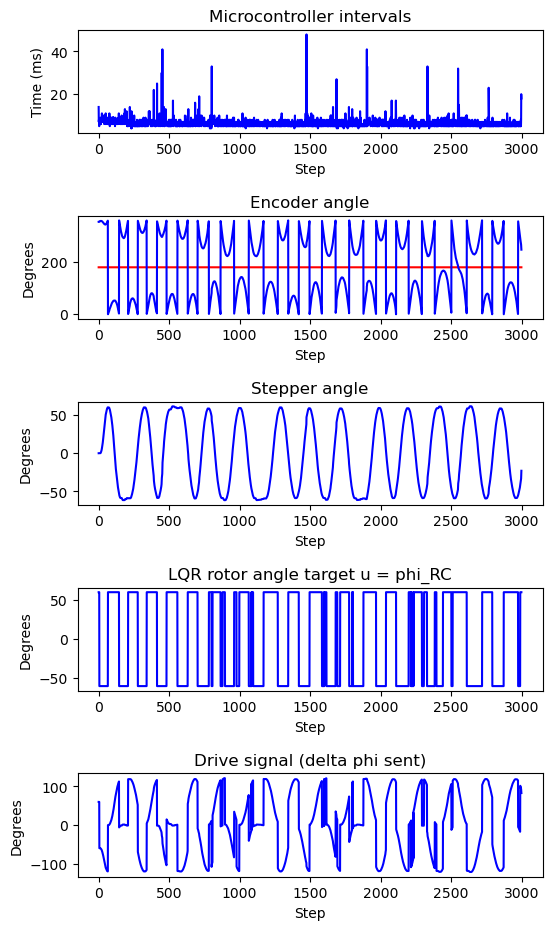

In [23]:
# ------------------------------------------------------------------
# LQR control loop (PDF Section 15). Same communication pattern as the
# G_rotor = 1 loop above, but u is an absolute rotor angle target:
# each cycle we send CMD_MOVE_BY (u_target - phi_measured).
# ------------------------------------------------------------------
LQR_THETA_REF_DEG = 180.0
LQR_PHI_REF_DEG = 0.0
LQR_NUM_STEPS = 3000

# Optional guard, disabled by default (same convention as above)
LQR_USE_ENC_GUARD = False
LQR_ENC_GUARD_DEGS = [5, 355]

STEP_MODE = STEP_MODE_16
STEP_DEG = 360.0 / (200 * STEP_DIVS[STEP_MODE])

lqr_controller = LQRRotorTargetController(
    K_LQR,
    theta_ref_deg=LQR_THETA_REF_DEG,
    phi_ref_deg=LQR_PHI_REF_DEG,
    derivative_tau=0.02,
    u_max_deg=60.0,
)
step_residual_deg = 0.0

# Metrics
lqr_intervals = []
lqr_enc_degs = []
lqr_stp_degs = []
lqr_u_degs = []
lqr_move_degs = []

resp = ctrl.step(CMD_SET_STEP_MODE, [STEP_MODE])
resp = ctrl.step(CMD_SET_BLOCK_MODE, [0])
resp = ctrl.step(CMD_SET_HOME, [0])
if resp:
    _, timestamp_prev, _, obs = resp
    lqr_controller.initialize(obs[0], obs[1])
else:
    print("ERROR: Could not communicate with Arduino")
    timestamp_prev = 0

delta_phi_send = 0.0
for i in range(LQR_NUM_STEPS):

    resp = ctrl.step(CMD_MOVE_BY, [delta_phi_send])
    if resp:
        status, timestamp, terminated, obs = resp
    else:
        print("ERROR: Could not communicate with Arduino")
        continue

    enc_deg = obs[0]    # Pendulum encoder angle (theta)
    stp_deg = obs[1]    # Stepper rotor angle (phi, wrapped)

    interval = timestamp - timestamp_prev
    timestamp_prev = timestamp
    dt = interval / 1000.0

    if dt <= 0.0 or dt > 0.1:
        delta_phi_send = 0.0
        continue

    # LQR: u = -Kx is the desired ABSOLUTE rotor angle (phi_RC, deg)
    u_deg, phi_unwrapped_deg = lqr_controller.update(enc_deg, stp_deg, dt)

    # Convert the target to a relative move from the current rotor angle
    delta_phi_deg = u_deg - phi_unwrapped_deg
    delta_phi_send = quantize_relative_command(delta_phi_deg, STEP_DEG)

    lqr_intervals.append(interval)
    lqr_enc_degs.append(enc_deg)
    lqr_stp_degs.append(stp_deg)
    lqr_u_degs.append(u_deg)
    lqr_move_degs.append(delta_phi_send)

    if LQR_USE_ENC_GUARD and (enc_deg < LQR_ENC_GUARD_DEGS[0]
                              or enc_deg > LQR_ENC_GUARD_DEGS[1]):
        print("Episode terminated")
        break

print(f"Average interval: {sum(lqr_intervals) / len(lqr_intervals)} ms")

fig, ax = plt.subplots(5, 1, figsize=(6, 11))
plt.subplots_adjust(hspace=0.8)

ax[0].plot(lqr_intervals, color='blue')
ax[0].set_title("Microcontroller intervals")
ax[0].set_ylabel("Time (ms)")
ax[0].set_xlabel("Step")

ax[1].plot([LQR_THETA_REF_DEG] * len(lqr_enc_degs), color='red')
ax[1].plot(lqr_enc_degs, color='blue')
ax[1].set_title("Encoder angle")
ax[1].set_ylabel("Degrees")
ax[1].set_xlabel("Step")

ax[2].plot(lqr_stp_degs, color='blue')
ax[2].set_title("Stepper angle")
ax[2].set_ylabel("Degrees")
ax[2].set_xlabel("Step")

ax[3].plot(lqr_u_degs, color='blue')
ax[3].set_title("LQR rotor angle target u = phi_RC")
ax[3].set_ylabel("Degrees")
ax[3].set_xlabel("Step")

ax[4].plot(lqr_move_degs, color='blue')
ax[4].set_title("Drive signal (delta phi sent)")
ax[4].set_ylabel("Degrees")
ax[4].set_xlabel("Step")

K_THETA     =   228.57 rad/s^2 per rad
K_THETA_DOT =    29.64 rad/s^2 per rad/s
K_PHI       =    -2.15 rad/s^2 per rad
K_PHI_DOT   =    -4.06 rad/s^2 per rad/s
Accel clip  = 5.30 rad/s^2 (saturates at ~1.33 deg of pendulum error)
Episode terminated
Average interval: 4.193018480492813 ms


Text(0.5, 0, 'Step')

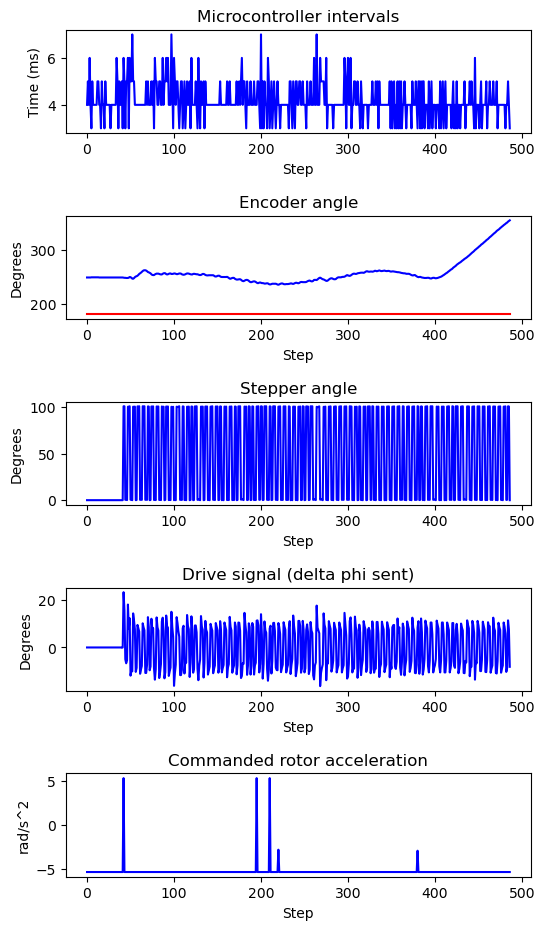

In [15]:
# ------------------------------------------------------------------
# Physical parameters (manual, Table 2) and simplified model
#   theta_ddot = d*theta_err + e*phi_ddot   (inverted, G_rotor = 1)
# ------------------------------------------------------------------
G_ACCEL = 9.81      # m/s^2
PEND_L = 0.235      # m, rotor arm to pendulum mass
ROTOR_R = 0.14      # m, rotor arm length

d_pend = G_ACCEL / PEND_L               # g/l ~ 41.74 s^-2 (unstable pole +-6.46)

# Coupling direction between rotor acceleration and pendulum angle as seen
# by THIS firmware. Flip to -1.0 if the pendulum falls away faster as soon
# as the controller runs.
COUPLING_SIGN = 1.0
e_pend = COUPLING_SIGN * (ROTOR_R / PEND_L)   # r/l ~ 0.596

# ------------------------------------------------------------------
# Gain design by pole placement.
# With u = phi_ddot_cmd = -k_t*th - k_td*th_dot - k_p*phi - k_pd*phi_dot
# the closed-loop characteristic polynomial is
#   s^4 + (e*k_td + k_pd)s^3 + (e*k_t + k_p - d)s^2 - d*k_pd*s - d*k_p
# Pendulum pair: zeta=0.7, wn=8 rad/s (above omega0 = 6.46 rad/s).
# Rotor pair: slow real poles so phi returns to phi_ref gently.
# ------------------------------------------------------------------
ZETA_PEND = 0.7
WN_PEND = 8.0
POLES_ROTOR = [-1.0, -1.4]

poles_pend = np.roots([1.0, 2.0 * ZETA_PEND * WN_PEND, WN_PEND**2])
dpoly = np.real(np.poly(np.concatenate([poles_pend, POLES_ROTOR])))

K_PHI       = -dpoly[4] / d_pend
K_PHI_DOT   = -dpoly[3] / d_pend
K_THETA_DOT = (dpoly[1] - K_PHI_DOT) / e_pend
K_THETA     = (dpoly[2] + d_pend - K_PHI) / e_pend

# Other controller constants
THETA_REF_DEG = 180.0       # Upright pendulum encoder angle
PHI_REF_DEG = 0.0           # Rotor reference (home)
DERIVATIVE_TAU = 0.02       # Derivative low-pass filter time constant (s)
NUM_STEPS = 1000000
# ENC_GUARD_DEGS = [160, 200]
ENC_GUARD_DEGS = [5, 355]
STEP_MODE = STEP_MODE_16

# One microstep in degrees (0.1125 deg at 1/16)
STEP_DEG = 360.0 / (200 * STEP_DIVS[STEP_MODE])

# Actuator limits from the .ino config: 3000 pps^2, 1000 pps at 1/16
# microstep -> ~5.9 rad/s^2 and ~2.0 rad/s. Clip commands below the
# hardware limit so the G_rotor = 1 assumption stays plausible.
ACCEL_HW_RAD_S2 = np.deg2rad(3000 * STEP_DEG)
MAX_ACCEL_RAD_S2 = 0.9 * ACCEL_HW_RAD_S2

print(f"K_THETA     = {K_THETA:8.2f} rad/s^2 per rad")
print(f"K_THETA_DOT = {K_THETA_DOT:8.2f} rad/s^2 per rad/s")
print(f"K_PHI       = {K_PHI:8.2f} rad/s^2 per rad")
print(f"K_PHI_DOT   = {K_PHI_DOT:8.2f} rad/s^2 per rad/s")
print(f"Accel clip  = {MAX_ACCEL_RAD_S2:.2f} rad/s^2 "
      f"(saturates at ~{np.rad2deg(MAX_ACCEL_RAD_S2 / K_THETA):.2f} deg of pendulum error)")

# Controller (G_rotor = 1 assumption)
controller = PendulumStateController(
    k_theta=K_THETA,
    k_theta_dot=K_THETA_DOT,
    k_phi=K_PHI,
    k_phi_dot=K_PHI_DOT,
    theta_ref_deg=THETA_REF_DEG,
    phi_ref_deg=PHI_REF_DEG,
    derivative_tau=DERIVATIVE_TAU,
    max_accel_rad_s2=MAX_ACCEL_RAD_S2,
)
step_residual_deg = 0.0

# Metrics to store
intervals = []
enc_degs = []
stp_degs = []
move_degs = []
accel_cmds = []

# Set step mode, non-blocking moves, current position as home, get timestamp
resp = ctrl.step(CMD_SET_STEP_MODE, [STEP_MODE])
resp = ctrl.step(CMD_SET_BLOCK_MODE, [0])
resp = ctrl.step(CMD_SET_HOME, [0])
if resp:
    _, timestamp_prev, _, obs = resp
    controller.initialize(obs[0], obs[1])
else:
    print("ERROR: Could not communicate with Arduino")
    timestamp_prev = 0

# Try to keep pendulum in upright position
delta_phi_send = 0.0
for i in range(NUM_STEPS):

    # Send the relative move and get an observation back
    resp = ctrl.step(CMD_MOVE_BY, [delta_phi_send])
    if resp:
        status, timestamp, terminated, obs = resp
    else:
        print("ERROR: Could not communicate with Arduino")
        continue

    # Get observation values (deg, wrapped to 0~360)
    enc_deg = obs[0]    # Pendulum encoder angle (theta)
    stp_deg = obs[1]    # Stepper rotor angle (phi)

    # Actual sample time from the microcontroller timestamps (ms -> s)
    interval = timestamp - timestamp_prev
    timestamp_prev = timestamp
    dt = interval / 1000.0

    # Skip abnormal sample periods
    if dt <= 0.0 or dt > 0.1:
        delta_phi_send = 0.0
        continue

    # State feedback -> relative displacement (G_rotor = 1 assumption)
    delta_phi_deg, phi_ddot_cmd, phi_dot_est = controller.update(
        enc_deg,
        stp_deg,
        dt
    )

    # Quantize to whole microsteps, carrying the fractional residual
    delta_phi_send = quantize_relative_command(delta_phi_deg, STEP_DEG)

    # Store metrics
    intervals.append(interval)
    move_degs.append(delta_phi_send)
    enc_degs.append(enc_deg)
    stp_degs.append(stp_deg)
    accel_cmds.append(phi_ddot_cmd)

    # Stop if encoder goes past one of our guard angles
    if enc_deg < ENC_GUARD_DEGS[0] or enc_deg > ENC_GUARD_DEGS[1]:
        print("Episode terminated")
        break

# Calculate average interval
print(f"Average interval: {sum(intervals) / len(intervals)} ms")

# Create plots
fig, ax = plt.subplots(5, 1, figsize=(6, 11))
plt.subplots_adjust(hspace=0.8)

# Plot intervals measured from microcontroller
ax[0].plot(intervals, color='blue')
ax[0].set_title("Microcontroller intervals")
ax[0].set_ylabel("Time (ms)")
ax[0].set_xlabel("Step")

# Plot setpoint and encoder degrees
ax[1].plot([THETA_REF_DEG] * len(enc_degs), color='red')
ax[1].plot(enc_degs, color='blue')
ax[1].set_title("Encoder angle")
ax[1].set_ylabel("Degrees")
ax[1].set_xlabel("Step")

# Plot stepper degrees
ax[2].plot(stp_degs, color='blue')
ax[2].set_title("Stepper angle")
ax[2].set_ylabel("Degrees")
ax[2].set_xlabel("Step")

# Plot output signals (relative moves actually sent)
ax[3].plot(move_degs, color='blue')
ax[3].set_title("Drive signal (delta phi sent)")
ax[3].set_ylabel("Degrees")
ax[3].set_xlabel("Step")

# Plot commanded rotor acceleration
ax[4].plot(accel_cmds, color='blue')
ax[4].set_title("Commanded rotor acceleration")
ax[4].set_ylabel("rad/s^2")
ax[4].set_xlabel("Step")